<a href="https://colab.research.google.com/github/tozdty/grilled-cheese-thermal-model/blob/main/grilled_cheese_keff.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.linalg import solve_banded
from scipy.optimize import minimize_scalar

import os
import warnings
from IPython.display import HTML


try:
    import heatrapy as htp
    HEATRAPY_AVAILABLE = True
except ImportError:
    HEATRAPY_AVAILABLE = False
    print("Heatrapy not found. Install in the Colab Terminal with: pip install heatrapy")
    print("then run the cell again")


# MSE 3210 Final Project - Effective Thermal Conductivity of a Grilled Cheese Sandwich
---

![Grilled Cheese Sandwich](https://raw.githubusercontent.com/tozdty/grilled-cheese-thermal-model/main/Grilled%20Cheese.jpg)

## Section 1 - Concept & Demonstration

### Transport Phenomenon
This project investigates the **effective thermal conductivity** ($k_{\text{eff}}$) of a grilled cheese sandwich subject to **1D heat conduction** on one side.


Why $k_{\text{eff}}$?
The sandwich is a composite of two materials with significantly different microstructures:

- **Bread** is a highly porous solid ($v_v \approx 0.6$–$0.8$) whose conductivity is dominated
  by its air void fraction rather than the solid matrix alone.
- **Cheese** is a dense, low-porosity solid whose conductivity is well-approximated by a single
  literature value.




### Demonstration

A grilled cheese sandwich is assembled using sliced Colby cheese and an English muffin.
The experiment measures the internal temperature history to calculate the **effective thermal conductivity** ($k_{\text{eff}}$) of the sandwich.





In [ ]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    display(HTML('<iframe width="415" height="737" src="https://www.youtube.com/embed/a1TPBfXsUj4" title="Grilled Cheese" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" referrerpolicy="strict-origin-when-cross-origin" allowfullscreen></iframe>'))

---
## Section 2 - Model & Governing Equation

### Governing Equation — 1D Heat Equation, No Generation
1D transient conduction through the sandwich, treated as a homogeneous slab with $k_{\text{eff}}$:
$$\frac{\partial T}{\partial t} = \alpha_{\text{eff}} \frac{\partial^2 T}{\partial x^2}, \qquad 0 \leq x \leq L, \qquad \alpha_{\text{eff}} = \frac{k_{\text{eff}}}{\rho_{\text{eff}} C_{p,\text{eff}}}$$


### Grilled Cheese Sandwich Schematic
![Sandwich schematic](https://raw.githubusercontent.com/tozdty/grilled-cheese-thermal-model/5a8a563f69f73fc34a8b10ba6e1e35e5aacbe45f/grilled%20cheese%20schematic.png)



### Boundary & Initial Conditions
- **IC:** $T(x, 0) = T_0$ — sandwich equilibrated to room temperature before placement.
- **BC1** ($x = 0$, pan side): $T(0, t) = T_{\text{pan}}$ — constant surface temperature (Dirichlet), verified with IR thermometer.
- **BC2** ($x = L$, air side): $-k_{\text{eff}}\,\partial T/\partial x\big|_{x=L} = h\,(T(L,t) - T_{\infty})$ — convective loss to still air (Robin).

The domain runs from $x = 0$ (pan surface) to $x = L$ (exposed air side),
with $L = 2L_b + L_c$.



### Assumptions
1. 1D conduction only (edge losses ignored).
2. Layers combined in series — heat flow is perpendicular to each layer (consistent with 1D model).
3. Bread is a two-phase porous solid (solid matrix + air); EMT applies.
4. $k_{\text{cheese}}$ is homogeneous and constant.
5. The composite sandwich is represented by a single $k_{\text{eff}}$.
6. Radiation is negligible.
7. Pan surface is at a constant, uniform temperature $T_{\text{pan}}$.
8. Thermophysical properties are constant over the temperature range.
9. Contact resistance at bread–pan interface can be ignored.
10. Bread slices are cylindrical (English Muffin)



**Approach:**
- $k_{\text{bread}}$ is predicted analytically using Effective Medium Theory (EMT) applied to bread as a porous solid (solid matrix + air voids).
- $k_{\text{cheese}}$ is taken from literature as a single value.

- The three layers (bread / cheese / bread) are combined in series to yield $k_{\text{eff}}$ for the full sandwich.

- Volume-averaged bulk properties for $\rho_{\text{eff}}$ and $C_{p,\text{eff}}$ are calculated for the full sandwich.


Building $k_{\text{eff}}$ from Material Properties
---

**Find $k_{\text{bread}}$ using EMT**:

$$v_s \frac{k_s - k_{\text{bread}}}{k_s + 2k_{\text{bread}}} + v_v \frac{k_v - k_{\text{bread}}}{k_v + 2k_{\text{bread}}} = 0$$

Multiplying out and collecting terms yields a quadratic with analytical solution:

$$k_{\text{bread}} = \frac{b_0 + \sqrt{b_0^2 + 8k_s k_v}}{4}, \qquad b_0 = k_s(2v_s - v_v) + k_v(2v_v - v_s)$$

| Symbol | Description | Units |
|---|---|---|
| $k_s$ | Thermal conductivity of solid matrix (starch/gluten) | W/(m·K) |
| $k_v$ | Thermal conductivity of air voids | W/(m·K) |
| $v_s$ | Volume fraction of solid matrix | |
| $v_v$ | Volume fraction of air voids (porosity) ||
| $k_{\text{bread}}$ | Effective thermal conductivity of bread | W/(m·K) |

---

**Find combination of thermal resistance** across the three layers (bread / cheese / bread):

$R_{\text{total}} = R_{\text{bread}} + R_{\text{cheese}} + R_{\text{bread}}$, where $R = L_i / k_i$ per unit area.

$$k_{\text{eff}} = \frac{L}{\dfrac{2L_b}{k_{\text{bread}}} + \dfrac{L_c}{k_{\text{cheese}}}}$$

| Symbol | Description | Units |
|---|---|---|
| $L_b$ | Thickness of each bread slice | m |
| $L_c$ | Thickness of cheese layer | m |
| $L$ | Total sandwich thickness $= 2L_b + L_c$ | m |
| $k_{\text{cheese}}$ | Thermal conductivity of cheese | W/(m·K) |
| $k_{\text{eff}}$ | Effective thermal conductivity of sandwich | W/(m·K) |

---

**Find Volume-averaged bulk properties** for $\rho_{\text{eff}}$ and $C_{p,\text{eff}}$:

$$\rho_{\text{eff}} C_{p,\text{eff}} = \frac{2L_b \rho_{\text{bread}} C_{p,\text{bread}} + L_c \rho_{\text{cheese}} C_{p,\text{cheese}}}{L}$$

| Symbol | Description | Units |
|---|---|---|
| $\rho_{\text{bread}}$, $\rho_{\text{cheese}}$ | Density of bread and cheese | kg/m³ |
| $C_{p,\text{bread}}$, $C_{p,\text{cheese}}$ | Specific heat of bread and cheese | J/(kg·K) |
| $\rho_{\text{eff}} C_{p,\text{eff}}$ | Volume-averaged thermal mass of sandwich | J/(m³·K) |
| $\alpha_{\text{eff}}$ | Effective thermal diffusivity $= k_{\text{eff}} / (\rho_{\text{eff}} C_{p,\text{eff}})$ | m²/s |

In [ ]:
# ─── Section 2 Parameters ────────────────────────────────────────────────────

# ⚠️  FLAG: measure these experimentally
T_pan  = 172   # [°C]  Pan surface temperature at 340F — IR thermometer at t=0
T_inf  = 25   # [°C]  Ambient air temperature  — probe away from pan
T0     = 22.9   # [°C]  Initial sandwich temperature — equilibrate to room temp first

L_b    = 0.0141   # [m]   Thickness of each bread slice
L_c    = 0.004   # [m]   Thickness of cheese layer
m_bread = 0.031   # [kg]  mass of one slice
d_bread = 0.09   # [m]   diameter of bread

#Literature values
# ─── Bread: bulk properties ───────────────────────────────────────────────────
# Type:English Muffin
V_bread   = 3.14159 * (d_bread / 2)**2 * L_b   # [m³]
rho_bread = m_bread / V_bread                   # [kg/m³]
Cp_bread  = 2600.0                              # [J/(kg·K)]  [1, Table 5]

# ─── constituent phase properties for EMT ─────────────────────────────
rho_solid = 1300.0  # [kg/m³]  starch/gluten matrix at 20°C [2, Table 3]
v_v       = 1 - rho_bread / rho_solid
v_s       = 1 - v_v

k_s = 0.20   # [W/(m·K)]  [2, Table 2]
k_v = 0.026  # [W/(m·K)]  [2, Table 2]

# Wiener bounds for k_bread range check (computed from k_s, k_v, v_s, v_v above)
k_bread_lo = 1 / (v_s/k_s + v_v/k_v)  # series lower bound [1, Table 7]
k_bread_hi = k_s*v_s + k_v*v_v         # parallel upper bound [1, Table 7]

# ─── Cheese: bulk properties ─────────────────────────────────────────────────
#Type: Colby
k_cheese   = 0.40    # [W/(m·K)]  Colby ≈ high-moisture Cheddar [3, Table II]
rho_cheese = 1100.0  # [kg/m³]    Cheddar [3, Materials & Methods]
Cp_cheese  = 2800.0  # [J/(kg·K)] Cheddar DSC, mid-range [3, Table II]

# ─── Convection ───────────────────────────────────────────────────────────────
h = 5.0   # [W/(m²·K)]  still air natural convection, typical range 2–10

# ─── Guard ───────────────────────────────────────────────────────────────────
required = {'T_pan': T_pan, 'T_inf': T_inf, 'T0': T0, 'L_b': L_b, 'L_c': L_c}
missing  = [k for k, v in required.items() if v is None]

if missing:
    print(f"⚠️  The following variables must be set before analysis: {missing}")
else:
    L = 2*L_b + L_c
    print(f"Geometry: L_b={L_b*1e3:.1f} mm | L_c={L_c*1e3:.1f} mm | L={L*1e3:.1f} mm total")
    print("All required parameters defined. Proceed.")

Geometry: L_b=14.1 mm | L_c=4.0 mm | L=32.2 mm total
All required parameters defined. Proceed.


## Section 3 — Measurements & Data Collection

**What was measured:**
- $T_{\text{pan}}$: pan surface temperature (IR thermometer, at $t = 0$)
- $T_{\infty}$: ambient air temperature (probe thermometer, away from pan)
- $T_0$: initial sandwich temperature (probe at centre before placement)
- $T(x_{\text{probe}}, t)$: temperature at probe depth vs. time (probe thermometer)
- $L_b$, $L_c$: individual layer thicknesses (caliper)

**Tools:** cast iron pan, induction stovetop, scale, phone camera (IR thermometer, timer), probe thermometer, caliper, spatula, butter knife

**Ingredients:** colby cheese, english muffin, ghee

**Experimental Method**
- Sandwich dimensions (bread thickness, cheese thickness, bread diameter) and mass are measured with a caliper and scale
- A probe thermometer is inserted horizontally through the side of the sandwich to a known depth $x_{\text{probe}}$
- The sandwich is assembled
- The sandwich is allowed to equilibrate to room temperature; $T_0$ and $T_{\infty}$ are recorded
- Ghee is spread on the exterior of both bread slices and allowed to absorb for 1 minute
- The cast iron pan is preheated to 350°F (175°C) on an induction stovetop; $T_{\text{pan}}$ is verified with an IR thermometer
- The sandwich is placed on the pan and internal temperature is recorded every until the internal temperature reaches 65°C
- The sandwich is not flipped during for the duration of the temperature measurement period, preserving the 1D boundary conditions assumed by the model

Data loaded: 14 points | t=[0, 123] s | T=[22.9, 65.8] °C


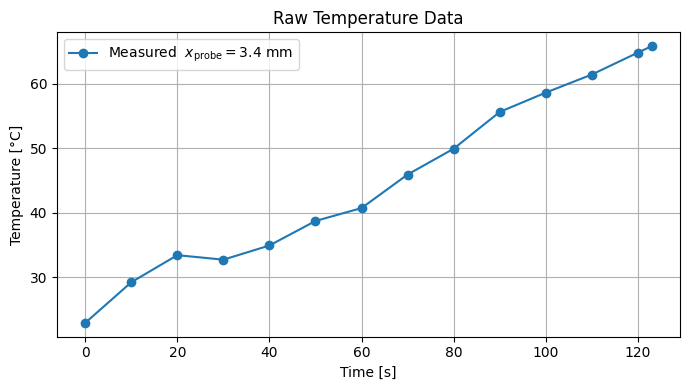

In [ ]:
# ─── Section 3: Raw Experimental Data ────────────────────────────────────────
# ⚠️  FLAG: replace with actual recorded values

# Time vector [s]
t_data = np.array([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 123])

# Temperature at probe location [°C]
T_data = np.array([22.9, 29.2, 33.4, 32.7, 34.9, 38.7, 40.7, 45.9, 49.9, 55.6, 58.6, 61.4, 64.8, 65.8])

#⚠️ probe depth from pan-side surface
x_probe = 0.0034 # [m] #Error corrected - Estimate 1 L/2, Estimate 2: L/8
# Sanity check + raw data plot
if t_data.size == 0 or T_data.size == 0:
    print("⚠️  t_data and T_data are empty — enter experimental measurements.")
elif t_data.size != T_data.size:
    print("⚠️  t_data and T_data must have the same length.")
else:
    print(f"Data loaded: {t_data.size} points | "
          f"t=[{t_data[0]:.0f}, {t_data[-1]:.0f}] s | "
          f"T=[{T_data[0]:.1f}, {T_data[-1]:.1f}] °C")
    plt.figure(figsize=(7, 4))
    plt.plot(t_data, T_data, 'o-', label=f'Measured  $x_{{\\rm probe}}={x_probe*1e3:.1f}$ mm')
    plt.xlabel('Time [s]'); plt.ylabel('Temperature [°C]')
    plt.title('Raw Temperature Data')
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

---
## Section 4 - Analysis & Calculation



1. Solve the EMT equation for $k_{\text{bread}}$ and compare against Series and Parallel bounds

Bread layer conductivity:
  Series   (lower bound) : 0.0338 W/(m·K)
  EMT      (used below)  : 0.0487 W/(m·K)  <--
  Parallel (upper bound) : 0.0723 W/(m·K)

  Sanity check passed: k_series ≤ k_bread ≤ k_parallel
  Void fraction v_v = 0.73  |  k_s = 0.2 W/(m·K)  |  k_v = 0.026 W/(m·K)
  ✓ k_bread is within the expected range [0.03382259563994548, 0.07225662514621892] W/(m·K).


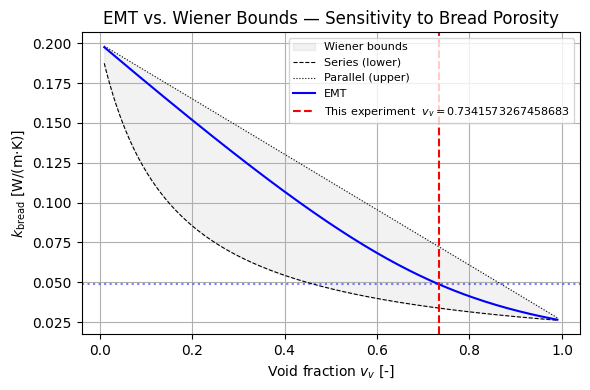

In [ ]:
def emt_analytical(k_s, k_v, v_s, v_v):
    b0 = k_s*(2*v_s - v_v) + k_v*(2*v_v - v_s)
    return (b0 + np.sqrt(b0**2 + 8*k_s*k_v)) / 4

k_bread = emt_analytical(k_s, k_v, v_s, v_v)

# Wiener bounds — k_bread must fall between these by construction
k_series   = 1 / (v_s/k_s + v_v/k_v)   # lower bound (series resistances)
k_parallel = k_s*v_s + k_v*v_v          # upper bound (parallel resistances)

print("Bread layer conductivity:")
print(f"  Series   (lower bound) : {k_series:.4f} W/(m·K)")
print(f"  EMT      (used below)  : {k_bread:.4f} W/(m·K)  <--")
print(f"  Parallel (upper bound) : {k_parallel:.4f} W/(m·K)")
assert k_series <= k_bread <= k_parallel, "EMT result outside Wiener bounds — check inputs"
print(f"\n  Sanity check passed: k_series ≤ k_bread ≤ k_parallel")
print(f"  Void fraction v_v = {v_v:.2f}  |  k_s = {k_s} W/(m·K)  |  k_v = {k_v} W/(m·K)")

if k_bread_lo <= k_bread <= k_bread_hi:
    print(f"  ✓ k_bread is within the expected range [{k_bread_lo}, {k_bread_hi}] W/(m·K).")
else:
    print(f"  ⚠️  k_bread is OUTSIDE the expected range [{k_bread_lo}, {k_bread_hi}] W/(m·K).")
    print("      Review porosity estimate and constituent k values.")

# ── Sensitivity: k_bread(EMT) vs. void fraction with Wiener bounds ────────────
v_v_range = np.linspace(0.01, 0.99, 200)
k_emt_range = np.array([emt_analytical(k_s, k_v, 1-vv, vv) for vv in v_v_range])
k_ser_range  = np.array([1/((1-vv)/k_s + vv/k_v) for vv in v_v_range])
k_par_range  = np.array([k_s*(1-vv) + k_v*vv     for vv in v_v_range])

plt.figure(figsize=(6, 4))
plt.fill_between(v_v_range, k_ser_range, k_par_range,
                 alpha=0.1, color='gray', label='Wiener bounds')
plt.plot(v_v_range, k_ser_range,  'k--', linewidth=0.8, label='Series (lower)')
plt.plot(v_v_range, k_par_range,  'k:',  linewidth=0.8, label='Parallel (upper)')
plt.plot(v_v_range, k_emt_range,  'b-',                 label='EMT')
plt.axvline(v_v, color='red', linestyle='--', label=f'This experiment  $v_v={v_v}$')
plt.axhline(k_bread, color='blue', linestyle=':', alpha=0.5)
plt.xlabel('Void fraction $v_v$ [-]')
plt.ylabel('$k_{\\rm bread}$ [W/(m·K)]')
plt.title('EMT vs. Wiener Bounds — Sensitivity to Bread Porosity')
plt.legend(fontsize=8); plt.grid(True); plt.tight_layout(); plt.show()

2. Combine layers in series to obtain $k_{\text{eff}}$ for the full sandwich, then compute $\alpha_{\text{eff}}$.

In [ ]:
# Thermal resistance in series (per unit area):
#   R_total = R_bread1 + R_cheese + R_bread2
#           = L_b/k_bread + L_c/k_cheese + L_b/k_bread
#           = 2*L_b/k_bread + L_c/k_cheese
#
# Effective conductivity: k_eff = L / R_total


prereqs = [L_b, L_c]
if any(v is None for v in prereqs):
    print("⚠️  Set L_b and L_c in Section 2 before running this cell.")
else:
    L = 2*L_b + L_c

    R_bread = 2*L_b / k_bread    # [m²·K/W]  both bread slices combined
    R_cheese = L_c / k_cheese    # [m²·K/W]
    R_total  = R_bread + R_cheese

    k_eff = L / R_total          # [W/(m·K)]  series effective conductivity

    # Volume-averaged bulk thermal mass for alpha_eff
    rhocp_eff = (2*L_b * rho_bread * Cp_bread + L_c * rho_cheese * Cp_cheese) / L
    alpha_eff = k_eff / rhocp_eff

    # Layer resistance fractions (useful for error discussion)
    f_bread  = R_bread  / R_total * 100
    f_cheese = R_cheese / R_total * 100

    print("Series combination — sandwich k_eff:")
    print(f"  k_bread  (EMT)         = {k_bread:.4f}  W/(m·K)")
    print(f"  k_cheese (literature)  = {k_cheese:.4f}  W/(m·K)")
    print(f"  R_bread  (both slices) = {R_bread:.4f}  m²·K/W  ({f_bread:.1f}% of R_total)")
    print(f"  R_cheese               = {R_cheese:.4f}  m²·K/W  ({f_cheese:.1f}% of R_total)")
    print(f"  k_eff    (sandwich)    = {k_eff:.4f}  W/(m·K)")
    print(f"  alpha_eff              = {alpha_eff:.3e}  m²/s")

Series combination — sandwich k_eff:
  k_bread  (EMT)         = 0.0487  W/(m·K)
  k_cheese (literature)  = 0.4000  W/(m·K)
  R_bread  (both slices) = 0.5786  m²·K/W  (98.3% of R_total)
  R_cheese               = 0.0100  m²·K/W  (1.7% of R_total)
  k_eff    (sandwich)    = 0.0547  W/(m·K)
  alpha_eff              = 4.677e-08  m²/s


3. Feed $k_{\text{eff}}$ and $\alpha_{\text{eff}}$ into the implicit FD solver and compare the predicted temperature history against the measured data for validation.

Forward model RMSE vs. data: 3.33 °C


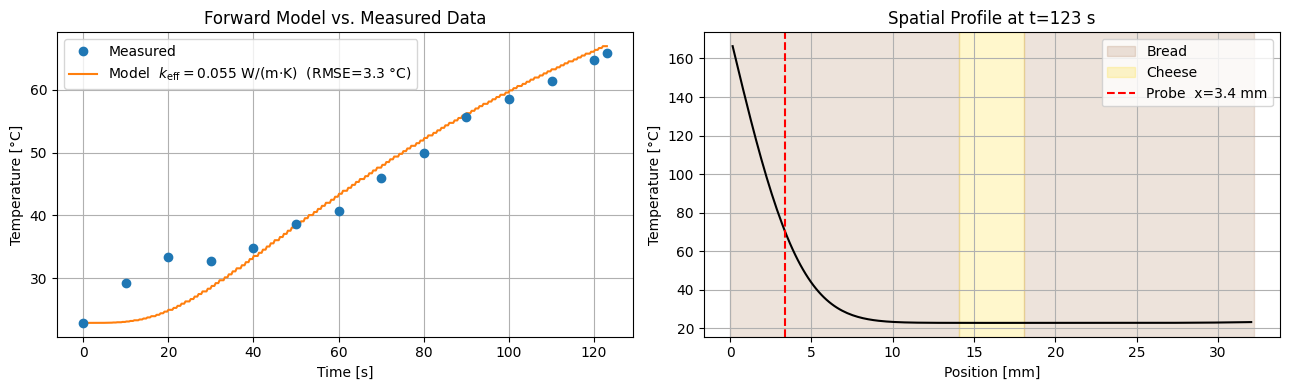

Best-fit x_probe = 3.4 mm  (measured: 3.4 mm)
RMSE at best-fit = 3.33 °C


In [ ]:
def simulate_homogeneous(k_eff, alpha_eff, t_query, x_probe,
                          L, T_pan, T0, T_inf, h,
                          N=100, dt=1.0):
    """
    Implicit backward-Euler FD solver for a homogeneous slab with k_eff, alpha_eff.

    BC1: Dirichlet  T(0, t)      = T_pan
    BC2: Robin     -k dT/dx|x=L = h*(T(L,t) - T_inf)

    Ghost node derivation for BC2:
      T_ghost = T_N*(1 - Bi) + Bi*T_inf,  Bi = h*dx/k_eff
    Substituting into the stencil at node N gives:
      diag[-1] = 1 + r*(1 + Bi)
    """
    dx = L / N
    x  = np.arange(0.5, N) * dx   # cell centres
    r  = alpha_eff * dt / dx**2

    diag  = np.full(N, 1 + 2*r)
    lower = np.full(N - 1, -r)
    upper = np.full(N - 1, -r)

    Bi = h * dx / k_eff
    diag[-1] = 1 + r*(1 + Bi)     # Robin BC — ghost node substitution

    ab = np.zeros((3, N))
    ab[0, 1:]  = upper
    ab[1, :]   = diag
    ab[2, :-1] = lower

    T     = np.full(N, T0, dtype=float)
    t_now = 0.0
    t_q   = np.asarray(t_query, dtype=float)
    T_out = np.empty_like(t_q)
    q_idx = 0

    probe_idx = int(np.argmin(np.abs(x - x_probe)))

    while q_idx < len(t_q) and t_q[q_idx] <= t_now:
        T_out[q_idx] = T[probe_idx]; q_idx += 1

    while q_idx < len(t_q):
        rhs      = T.copy()
        rhs[0]  += r * T_pan
        rhs[-1] += r * Bi * T_inf
        T        = solve_banded((1, 1), ab, rhs)
        t_now   += dt
        while q_idx < len(t_q) and t_q[q_idx] <= t_now + 1e-9:
            T_out[q_idx] = T[probe_idx]; q_idx += 1

    return T_out, x

# ── Run forward model and plot ────────────────────────────────────────────────
prereqs = [T_pan, T_inf, T0, L_b, L_c, x_probe]
if any(v is None for v in prereqs) or t_data.size == 0:
    print("⚠️  Set all flagged variables and enter data before running validation.")
else:
    L = 2*L_b + L_c
    t_fine = np.linspace(t_data[0], t_data[-1], 400)

    T_model, x_nodes = simulate_homogeneous(
        k_eff, alpha_eff, t_fine, x_probe,
        L, T_pan, T0, T_inf, h
    )

    # Residuals at measurement times for RMSE
    T_model_at_data, _ = simulate_homogeneous(
        k_eff, alpha_eff, t_data, x_probe,
        L, T_pan, T0, T_inf, h
    )
    rmse = np.sqrt(np.mean((T_model_at_data - T_data)**2))

    print(f"Forward model RMSE vs. data: {rmse:.2f} °C")

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # ── Plot 1: Temperature vs. time at probe ─────────────────────────────────
    ax = axes[0]
    ax.plot(t_data, T_data, 'o', label='Measured', zorder=5)
    ax.plot(t_fine, T_model, '-',
            label=f'Model  $k_{{\\rm eff}}={k_eff:.3f}$ W/(m·K)  (RMSE={rmse:.1f} °C)')
    ax.set_xlabel('Time [s]'); ax.set_ylabel('Temperature [°C]')
    ax.set_title('Forward Model vs. Measured Data')
    ax.legend(); ax.grid(True)

    # ── Plot 2: Spatial temperature profile at final measurement time ──────────
    def spatial_profile_at(t_end, N=200, dt=1.0):
        dx = L / (N + 1)
        x  = np.linspace(dx, L - dx, N)
        r  = alpha_eff * dt / dx**2
        diag  = np.full(N, 1 + 2*r)
        lower = np.full(N - 1, -r)
        upper = np.full(N - 1, -r)
        Bi = h * dx / k_eff
        diag[-1] = 1 + r*(1 + Bi)
        ab = np.zeros((3, N))
        ab[0,1:] = upper; ab[1,:] = diag; ab[2,:-1] = lower
        T = np.full(N, T0, dtype=float)
        for _ in range(int(np.ceil(t_end / dt))):
            rhs = T.copy()
            rhs[0]  += r * T_pan
            rhs[-1] += r * Bi * T_inf
            T = solve_banded((1, 1), ab, rhs)
        return x, T

    x_sp, T_sp = spatial_profile_at(t_data[-1])

    ax2 = axes[1]
    ax2.plot(x_sp * 1e3, T_sp, 'k-', linewidth=1.5)
    ax2.axvspan(0,               L_b*1e3,           alpha=0.15, color='saddlebrown', label='Bread')
    ax2.axvspan(L_b*1e3,        (L_b+L_c)*1e3,      alpha=0.20, color='gold',        label='Cheese')
    ax2.axvspan((L_b+L_c)*1e3,  (2*L_b+L_c)*1e3,   alpha=0.15, color='saddlebrown')
    ax2.axvline(x_probe*1e3, color='red', linestyle='--',
                label=f'Probe  x={x_probe*1e3:.1f} mm')
    ax2.set_xlabel('Position [mm]'); ax2.set_ylabel('Temperature [°C]')
    ax2.set_title(f'Spatial Profile at t={t_data[-1]:.0f} s')
    ax2.legend(); ax2.grid(True)

    plt.tight_layout(); plt.show()


## Substitute x_probe_mm value if probe position was off
def rmse_vs_xprobe(x_probe_mm):
    x_probe_fit = x_probe_mm / 1000
    T_fit, _ = simulate_homogeneous(k_eff, alpha_eff, t_data, x_probe_fit,
                                     L, T_pan, T0, T_inf, h)
    return np.sqrt(np.mean((T_fit - T_data)**2))

result = minimize_scalar(rmse_vs_xprobe, bounds=(1, L*1000), method='bounded')
x_probe_fit = result.x
rmse_fit    = result.fun

print(f"Best-fit x_probe = {x_probe_fit:.1f} mm  (measured: {x_probe*1e3:.1f} mm)")
print(f"RMSE at best-fit = {rmse_fit:.2f} °C")

4. Verify the manual FD solver against [heatrapy](https://github.com/djsilva99/heatrapy) using identical parameters and boundary conditions.

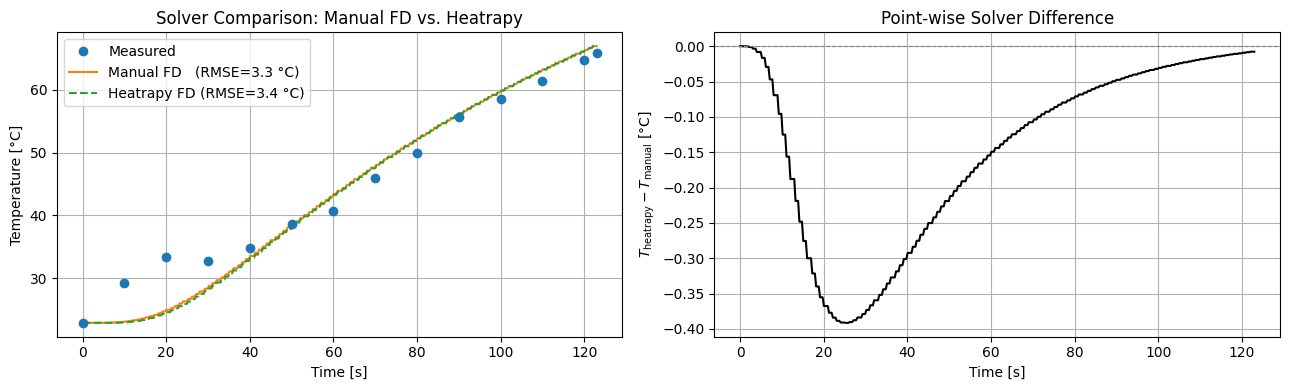

In [ ]:
# Heatrapy uses a node-based FD scheme with material property files.
# Robin BC: heatrapy only supports Dirichlet or insulated BCs natively.
# The Robin condition is applied by updating the right ghost node temperature
# at each timestep using the explicit approximation:
#   T_ghost = T_N - Bi*(T_N - T_inf),  Bi = h*dx/k_eff
# This is consistent with the ghost-node derivation in 4c.

HEATRAPY_MAT_PATH = '/content/heatrapy_materials/'
mat_dir = os.path.join(HEATRAPY_MAT_PATH, 'sandwich')
os.makedirs(mat_dir, exist_ok=True)


def write_heatrapy_material(mat_dir, k, rho, Cp,
                             T_lo=250, T_hi=500):
    """Write heatrapy material property files for a constant-property material."""

    for fname, val in [('k0.txt', k),  ('cp0.txt', Cp), ('rho0.txt', rho),
                       ('ka.txt', k),  ('cpa.txt', Cp), ('rhoa.txt', rho)]:
        with open(os.path.join(mat_dir, fname), 'w') as f:
            f.write(f'{T_lo}\t{val}\n{T_hi}\t{val}\n')
    for fname in ['tadi.txt', 'tadd.txt']:
        with open(os.path.join(mat_dir, fname), 'w') as f:
            f.write(f'{T_lo}\t0\n{T_hi}\t0\n')
    for fname in ['lheat0.txt', 'lheata.txt']:
        open(os.path.join(mat_dir, fname), 'w').close()


def simulate_heatrapy(k_eff, alpha_eff, t_query, x_probe,
                       L, T_pan, T0, T_inf, h,
                       N=100, dt=1.0):
    """
    Heatrapy FD solver for a homogeneous slab.
    Material properties are derived from k_eff and alpha_eff = k_eff/(rho*Cp).
    Uses rho=1, Cp=k_eff/alpha_eff so that alpha is matched exactly.

    Robin BC at x=L applied via explicit ghost node update each timestep.
    Node layout: node 0 = left boundary, nodes 1..N = interior, node N+1 = right ghost.
    """
    # Derive rho*Cp from alpha_eff; set rho=1 for simplicity
    rhocp = k_eff / alpha_eff
    rho_eff = 1.0
    Cp_eff  = rhocp

    write_heatrapy_material(mat_dir, k_eff, rho_eff, Cp_eff)

    dx    = L / N
    Bi    = h * dx / k_eff
    T0_K  = T0    + 273.15
    Tpan_K = T_pan + 273.15
    Tinf_K = T_inf + 273.15

    obj = htp.SingleObject1D(
        amb_temperature=T0_K,
        materials=('sandwich',),
        borders=(1, N + 1),
        materials_order=(0,),
        dx=dx, dt=dt,
        file_name=None,
        boundaries=(Tpan_K, 0),   # right=0 (insulated) — overridden each step
        initial_state=False,
        materials_path=HEATRAPY_MAT_PATH,
        draw=[]
    )

    t_q   = np.asarray(t_query, dtype=float)
    T_out = np.empty_like(t_q)
    q_idx = 0

    # Cell centres at (i-0.5)*dx for i=1..N; find probe node (1-indexed)
    x_centres = np.arange(0.5, N) * dx
    probe_idx = int(np.argmin(np.abs(x_centres - x_probe))) + 1  # +1 for left ghost

    t_now = 0.0
    while q_idx < len(t_q) and t_q[q_idx] <= t_now:
        T_out[q_idx] = obj.object.temperature[probe_idx][0] - 273.15
        q_idx += 1

    while q_idx < len(t_q):
        # Update Robin ghost node from previous timestep temperature
        T_last = obj.object.temperature[N][0]
        T_ghost = T_last - Bi * (T_last - Tinf_K)
        obj.change_boundaries((Tpan_K, T_ghost))
        obj.compute(dt, 1, solver='implicit_k(x)', verbose=False)
        t_now += dt
        while q_idx < len(t_q) and t_q[q_idx] <= t_now + 1e-9:
            T_out[q_idx] = obj.object.temperature[probe_idx][0] - 273.15
            q_idx += 1

    return T_out

# ─── Run comparison ───────────────────────────────────────────────

prereqs = [T_pan, T_inf, T0, L_b, L_c, x_probe]
if not HEATRAPY_AVAILABLE:
    print("⚠️  Heatrapy not available — install with: !pip install heatrapy")
elif any(v is None for v in prereqs) or t_data.size == 0:
    print("⚠️  Set all flagged variables and enter data before running.")
else:
    L = 2*L_b + L_c
    t_fine = np.linspace(t_data[0], t_data[-1], 400)

    T_heatrapy = simulate_heatrapy(
        k_eff, alpha_eff, t_fine, x_probe,
        L, T_pan, T0, T_inf, h
    )
    T_heatrapy_at_data = simulate_heatrapy(
        k_eff, alpha_eff, t_data, x_probe,
        L, T_pan, T0, T_inf, h
    )
    rmse_heatrapy = np.sqrt(np.mean((T_heatrapy_at_data - T_data)**2))

    T_manual, _ = simulate_homogeneous(
        k_eff, alpha_eff, t_fine, x_probe,
        L, T_pan, T0, T_inf, h
    )
    max_diff = np.max(np.abs(T_heatrapy - T_manual))
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    ax = axes[0]
    ax.plot(t_data, T_data,     'o',  label='Measured',                     zorder=5)
    ax.plot(t_fine, T_manual,   '-',  label=f'Manual FD   (RMSE={rmse:.1f} °C)')
    ax.plot(t_fine, T_heatrapy, '--', label=f'Heatrapy FD (RMSE={rmse_heatrapy:.1f} °C)')
    ax.set_xlabel('Time [s]'); ax.set_ylabel('Temperature [°C]')
    ax.set_title('Solver Comparison: Manual FD vs. Heatrapy')
    ax.legend(); ax.grid(True)

    ax2 = axes[1]
    ax2.plot(t_fine, T_heatrapy - T_manual, 'k-')
    ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax2.set_xlabel('Time [s]')
    ax2.set_ylabel('$T_{\\rm heatrapy} - T_{\\rm manual}$ [°C]')
    ax2.set_title('Point-wise Solver Difference')
    ax2.grid(True)

    plt.tight_layout(); plt.show()

---
## Section 5 - Results & Interpretation

In [ ]:
# ─── Section 5: Results Summary ───────────────────────────────────────────────

prereqs = [T_pan, T_inf, T0, L_b, L_c, x_probe]
if any(v is None for v in prereqs) or t_data.size == 0:
    print("⚠️  Complete Sections 2–4 before printing results.")
else:
    L = 2*L_b + L_c

    print("=" * 58)
    print("RESULTS SUMMARY")
    print("=" * 58)
    print("-" * 58)
    print(f"  k_eff                   = {k_eff:.4f}  W/(m·K)")
    print(f"  alpha_eff               = {alpha_eff:.3e}  m²/s")
    print(f"  Bread share of R_total  = {f_bread:.1f}%")
    print(f"  Cheese share of R_total = {f_cheese:.1f}%")
    print(f"  Forward model RMSE      = {rmse:.2f}  °C")
    if HEATRAPY_AVAILABLE and 'rmse_heatrapy' in dir():
        print(f"  Heatrapy FD RMSE        = {rmse_heatrapy:.2f}  °C")
        print(f"  Max solver difference   = {max_diff:.3f}  °C")
    else:
        print("  Heatrapy RMSE           : run Section 4d to populate.")
    print("-" * 58)
    print("=" * 58)

RESULTS SUMMARY
----------------------------------------------------------
  k_eff                   = 0.0547  W/(m·K)
  alpha_eff               = 4.677e-08  m²/s
  Bread share of R_total  = 98.3%
  Cheese share of R_total = 1.7%
  Forward model RMSE      = 3.33  °C
  Heatrapy FD RMSE        = 3.44  °C
  Max solver difference   = 0.392  °C
----------------------------------------------------------


Based on the low $k_{\text{eff}}$, a grilled cheese sandwich behaves like a thermal insulator, with a very similar thermal conductivity to water ~ 0.6 W/(m·K). The series combination is dominated by the most resistive layer, and since $k_{\text{bread}} \ll k_{\text{cheese}}$, the bread slices control the overall $k_{\text{eff}}$
— this is reflected in the resistance fraction.

### Sources of Error

1. **Porosity uncertainty**: $v_v$ is the most sensitive input to the EMT model. A ±0.05 error in $v_v$ produces a substantial shift in $k_{\text{bread}}$ which is visible in the sensitivity plot.

2. **Cheese phase change** (melting): the cheese transitions from solid to a partially fluid state during cooking. The latent heat is not captured by constant-$C_p$ and the single-$k$ assumption may not hold near melt temperature.

3. **Non-constant pan temperature**: induction cycling causes $T_{\text{pan}}$ to vary; the Dirichlet BC assumes it is constant.

4. **Series assumption**: the series model is exact only if heat flow is strictly 1D and perpendicular to layers. Any lateral non-uniformity (uneven bread, partial melting of cheese) introduces error.

5. **Solid matrix conductivity $k_s$**: Different dough recipes introduces variation in literature values for starch/gluten.

6. **Oil at bread–pan interface**: oil fills surface pores and improves thermal contact relative to a dry interface. However, fat infiltration into the bread surface locally alters $\rho$, $C_p$, and $k$ near $x = 0$, which is not captured by the homogeneous slab model.

7. **Probe accuracy & precision**: probe thermometer has finite accuracy and precision. This impacts temperature readings via biasing and random noise.

8. **Measurement uncertainty**: accuracy of initial parameter measurements and probe placement during the experiment introduces sources of random error.

### Bibliography

[1] O. D. Baik, M. Marcotte, S. S. Sablani, and F. Castaigne, "Thermal and physical properties of bakery products," *Crit. Rev. Food Sci. Nutr.*, vol. 41, no. 5, pp. 321–352, 2001, doi: 10.1080/20014091091832.
Used for: $\rho_{\text{bread}}$ (Table 5), $C_{p,\text{bread}}$ (Table 5), Wiener bound forms (Table 7), $k_v$ and $k_s$ component equations (Tables 1–3).

[2] Y. Choi and M. R. Okos, "Effects of temperature and composition on the thermal properties of foods," in *Food Engineering and Process Applications*, vol. 1, M. Le Maguer and P. Jelen, Eds. London, U.K.: Elsevier Applied Science, 1986, pp. 41–77.
Used for: $k_s$, $k_v$, $\rho_{\text{solid}}$ matrix (component property equations, reproduced in [1] Tables 1–3).

[3] L. T. Marschoun, K. Muthukumarappan, and S. Gunasekaran, "Thermal properties of Cheddar cheese: experimental and modeling," *Int. J. Food Prop.*, vol. 4, no. 3, pp. 383–403, 2001, doi: 10.1081/JFP-100108644.
Used for: $k_{\text{cheese}}$, $\rho_{\text{cheese}}$, $C_{p,\text{cheese}}$ (Table II, experimental DSC and line heat source probe data).